In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import os


In [4]:
# Importing Data CVS File.
df = pd.read_csv(r"/Users/javieraquezada/Desktop/new_retail_data.csv")

In [5]:
# Creating Path 
path = r'/Users/javieraquezada/Desktop'

In [6]:
path

'/Users/javieraquezada/Desktop'

In [8]:
# Checking Data
df.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
0,8691788.0,37249.0,Michelle Harrington,Ebony39@gmail.com,1.414787e+09,3959 Amanda Burgs,Dortmund,Berlin,77985.0,Germany,...,324.086270,Clothing,Nike,Shorts,Excellent,Same-Day,Debit Card,Shipped,5.0,Cycling shorts
1,2174773.0,69749.0,Kelsey Hill,Mark36@gmail.com,6.852900e+09,82072 Dawn Centers,Nottingham,England,99071.0,UK,...,806.707815,Electronics,Samsung,Tablet,Excellent,Standard,Credit Card,Processing,4.0,Lenovo Tab
2,6679610.0,30192.0,Scott Jensen,Shane85@gmail.com,8.362160e+09,4133 Young Canyon,Geelong,New South Wales,75929.0,Australia,...,1063.432799,Books,Penguin Books,Children's,Average,Same-Day,Credit Card,Processing,2.0,Sports equipment
3,7232460.0,62101.0,Joseph Miller,Mary34@gmail.com,2.776752e+09,8148 Thomas Creek Suite 100,Edmonton,Ontario,88420.0,Canada,...,2466.854021,Home Decor,Home Depot,Tools,Excellent,Standard,PayPal,Processing,4.0,Utility knife
4,4983775.0,27901.0,Debra Coleman,Charles30@gmail.com,9.098268e+09,5813 Lori Ports Suite 269,Bristol,England,48704.0,UK,...,248.553049,Grocery,Nestle,Chocolate,Bad,Standard,Cash,Shipped,1.0,Chocolate cookies


In [10]:
# Data Exploration 
df.shape

(302010, 30)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302010 entries, 0 to 302009
Data columns (total 30 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction_ID    301677 non-null  float64
 1   Customer_ID       301702 non-null  float64
 2   Name              301628 non-null  object 
 3   Email             301663 non-null  object 
 4   Phone             301648 non-null  float64
 5   Address           301695 non-null  object 
 6   City              301762 non-null  object 
 7   State             301729 non-null  object 
 8   Zipcode           301670 non-null  float64
 9   Country           301739 non-null  object 
 10  Age               301837 non-null  float64
 11  Gender            301693 non-null  object 
 12  Income            301720 non-null  object 
 13  Customer_Segment  301795 non-null  object 
 14  Date              301651 non-null  object 
 15  Year              301660 non-null  float64
 16  Month             30

In [12]:
df.describe(include='all')

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
count,3.016770e+05,301702.000000,301628,301663,3.016480e+05,301695,301762,301729,301670.000000,301739,...,301660.000000,301727,301729,302010,301826,301673,301713,301775,301826.000000,302010
unique,NaN,NaN,159390,52897,NaN,299329,130,54,NaN,5,...,NaN,5,18,33,4,3,4,4,NaN,318
top,NaN,NaN,Michael Smith,Michael59@gmail.com,NaN,637 Abigail Trafficway,Chicago,England,NaN,USA,...,NaN,Electronics,Pepsi,Water,Excellent,Same-Day,Credit Card,Delivered,NaN,Spring water
freq,NaN,NaN,144,93,NaN,2,21652,63059,NaN,95223,...,NaN,71196,30292,24459,100755,104156,90116,130449,NaN,2508
mean,5.495823e+06,55006.553934,NaN,NaN,5.501464e+09,NaN,NaN,NaN,50298.951019,NaN,...,1367.651156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.162670,NaN
std,2.595565e+06,26005.675200,NaN,NaN,2.596017e+09,NaN,NaN,NaN,28972.807134,NaN,...,1128.998515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.320827,NaN
min,1.000007e+06,10000.000000,NaN,NaN,1.000049e+09,NaN,NaN,NaN,501.000000,NaN,...,10.003750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN
25%,3.247930e+06,32469.250000,NaN,NaN,3.255061e+09,NaN,NaN,NaN,25425.000000,NaN,...,438.724278,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,NaN
50%,5.499657e+06,55012.000000,NaN,NaN,5.505812e+09,NaN,NaN,NaN,50602.500000,NaN,...,1041.117547,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN
75%,7.739509e+06,77511.000000,NaN,NaN,7.749860e+09,NaN,NaN,NaN,75252.000000,NaN,...,2029.999853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,NaN


In [13]:
## Checking for missing values 
df.isnull().sum()

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              357
Total_Amount        350
Product_Category    283
Product_Brand       281
Product_Type          0
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
products              0
dtype: int64

In [30]:
# Check missing values before cleaning
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

Transaction_ID      333
Customer_ID         308
Name                382
Email               347
Phone               362
Address             315
City                248
State               281
Zipcode             340
Country             271
Age                 173
Gender              317
Income              290
Customer_Segment    215
Date                359
Year                350
Month               273
Time                350
Total_Purchases     361
Amount              356
Total_Amount        350
Product_Category    283
Product_Brand       281
Feedback            184
Shipping_Method     337
Payment_Method      297
Order_Status        235
Ratings             184
dtype: int64


In [31]:
# Show rows that have any missing values
missing_rows_before = df[df.isnull().any(axis=1)]
print(missing_rows_before)

        Transaction_ID  Customer_ID               Name                  Email  \
99           9823195.0      14549.0   Danielle Bennett      James20@gmail.com   
109          7379891.0      47846.0           Mary Kim  Katherine73@gmail.com   
113          7018142.0      67530.0  Mathew Fitzgerald       Erik18@gmail.com   
123          7361679.0      47748.0       Alexis Smith      Karen91@gmail.com   
142          5050125.0      14196.0    Michael Perkins    Tabitha57@gmail.com   
...                ...          ...                ...                    ...   
301738       4008043.0      78992.0         David King      Carla27@gmail.com   
301875       2629026.0      73981.0     Anthony Nelson      Julie40@gmail.com   
301883       2691972.0      39280.0        Chad Harvey    Timothy73@gmail.com   
301894       1105898.0      83447.0      Richard Smith    William82@gmail.com   
301998       9972131.0          NaN        Adam Knight     Joseph61@gmail.com   

               Phone       

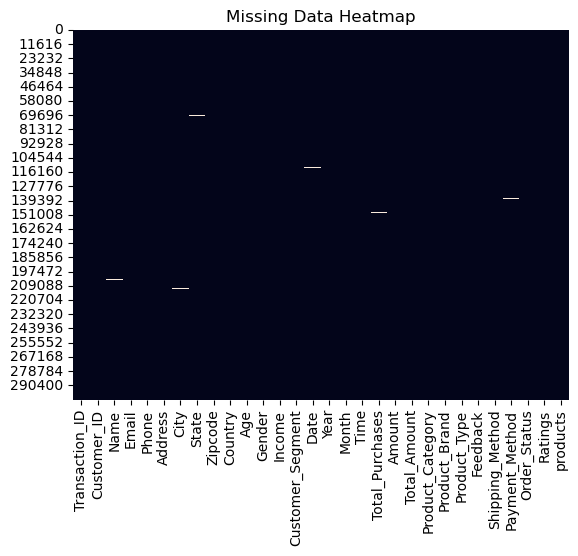

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize missing data pattern
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Data Heatmap')
plt.show()


In [34]:

# Check if missing data is related to a specific column, for example 'Country'
print(df[df['Phone'].isnull()]['Country'].value_counts())

Country
USA          119
UK            72
Australia     63
Germany       60
Canada        47
Name: count, dtype: int64


In [14]:
df.dtypes

Transaction_ID      float64
Customer_ID         float64
Name                 object
Email                object
Phone               float64
Address              object
City                 object
State                object
Zipcode             float64
Country              object
Age                 float64
Gender               object
Income               object
Customer_Segment     object
Date                 object
Year                float64
Month                object
Time                 object
Total_Purchases     float64
Amount              float64
Total_Amount        float64
Product_Category     object
Product_Brand        object
Product_Type         object
Feedback             object
Shipping_Method      object
Payment_Method       object
Order_Status         object
Ratings             float64
products             object
dtype: object

In [15]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Name', 'Email', 'Phone', 'Address',
       'City', 'State', 'Zipcode', 'Country', 'Age', 'Gender', 'Income',
       'Customer_Segment', 'Date', 'Year', 'Month', 'Time', 'Total_Purchases',
       'Amount', 'Total_Amount', 'Product_Category', 'Product_Brand',
       'Product_Type', 'Feedback', 'Shipping_Method', 'Payment_Method',
       'Order_Status', 'Ratings', 'products'],
      dtype='object')

In [18]:
#Checking for duplicates
df.duplicated().any()

True

In [19]:
duplicate_rows = df[df.duplicated()]
display(duplicate_rows)

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
299759,4476510.0,20103.0,Christine Kim,James11@gmail.com,2.383778e+09,8176 Randy Squares Apt. 772,Kitchener,Ontario,7099.0,Canada,...,940.619277,Clothing,Adidas,T-shirt,Bad,Express,Credit Card,Processing,1.0,Off-the-shoulder tee
301094,5340129.0,29920.0,Collin Davis,Courtney47@gmail.com,4.087767e+09,371 Cynthia Drives Suite 699,Wollongong,New South Wales,47758.0,Australia,...,2201.568075,Grocery,Pepsi,Soft Drink,Excellent,Express,Cash,Delivered,4.0,Fruit punch
301362,4942326.0,25416.0,Pamela Martin,Christine83@gmail.com,6.657934e+09,9851 Myers Tunnel,Leicester,England,57655.0,UK,...,1535.255087,Clothing,Adidas,Jacket,Average,Same-Day,Cash,Pending,2.0,Varsity jacket
301486,3200766.0,49598.0,Mikayla Mueller,Kenneth43@gmail.com,6.980439e+09,716 Joshua Rapids Apt. 790,Bremen,Berlin,64747.0,Germany,...,2450.946762,Grocery,Pepsi,Soft Drink,Bad,Standard,Cash,Pending,1.0,Iced tea


In [20]:
num_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {num_duplicates}")

Total duplicate rows: 4


In [21]:
## Dropping Duplicates 
df.drop_duplicates(inplace=True)

In [23]:
#Checking for duplicates
df.duplicated().any()

False

In [59]:
# Creating Random DF Sample
df_sample_2 = df.sample(n=10000, random_state=42)

In [60]:
# Preview the first 5 rows
df_sample_2.head()

,Transaction_ID,Customer_ID,Name,Email,Phone,Address,City,State,Zipcode,Country,...,Total_Amount,Product_Category,Product_Brand,Product_Type,Feedback,Shipping_Method,Payment_Method,Order_Status,Ratings,products
77037,8154457.0,18745.0,Tara Wright,Jeffrey100@gmail.com,6.443965e+09,474 Kevin Road Apt. 786,Chicago,Connecticut,14063.0,USA,...,2350.802482,Books,HarperCollins,Fiction,Excellent,Standard,PayPal,Processing,5.0,Historical fiction
106765,8896002.0,82300.0,Daniel Patton,Cheyenne19@gmail.com,1.792779e+09,717 Timothy Prairie,Brisbane,New South Wales,82508.0,Australia,...,605.991344,Clothing,Zara,Jeans,Excellent,Same-Day,Debit Card,Shipped,5.0,Wide-leg jeans
187652,1820950.0,49584.0,Kathleen Watson,Billy97@gmail.com,2.066960e+09,2069 Nicholas Prairie Suite 877,St. John's,Ontario,61208.0,Canada,...,676.659578,Grocery,Pepsi,Water,Bad,Standard,Credit Card,Shipped,1.0,Mineral water
184582,9448636.0,74580.0,Steven Sullivan,Gabriel71@gmail.com,8.490832e+09,912 Randall Manor,Saskatoon,Ontario,53361.0,Canada,...,272.016496,Home Decor,Bed Bath & Beyond,Bedding,Bad,Standard,Credit Card,Shipped,1.0,Mattress topper
290216,8088692.0,72061.0,Heather Yu,Daniel32@gmail.com,7.141601e+09,1297 Willis Drive,Halifax,Ontario,64745.0,Canada,...,2394.895305,Grocery,Nestle,Snacks,Good,Standard,Debit Card,Shipped,4.0,Chips


In [61]:
# DataFrame structure and non-null counts
df_sample_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 77037 to 136190
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    9992 non-null   float64
 1   Customer_ID       9991 non-null   float64
 2   Name              9988 non-null   object 
 3   Email             9991 non-null   object 
 4   Phone             9992 non-null   float64
 5   Address           9993 non-null   object 
 6   City              9994 non-null   object 
 7   State             9988 non-null   object 
 8   Zipcode           9991 non-null   float64
 9   Country           9994 non-null   object 
 10  Age               9993 non-null   float64
 11  Gender            9993 non-null   object 
 12  Income            9991 non-null   object 
 13  Customer_Segment  9996 non-null   object 
 14  Date              9990 non-null   object 
 15  Year              9989 non-null   float64
 16  Month             9993 non-null   object

In [62]:
# Shape of the DataFrame
df_sample_2.shape

(10000, 30)

In [63]:
# Check how many missing values per column
df_sample_2.isnull().sum().sort_values(ascending=False)

Time                15
Product_Brand       13
Name                12
Order_Status        12
Payment_Method      12
Shipping_Method     12
State               12
Year                11
Date                10
Income               9
Customer_ID          9
Zipcode              9
Total_Amount         9
Email                9
Amount               8
Product_Category     8
Total_Purchases      8
Transaction_ID       8
Phone                8
Month                7
Gender               7
Age                  7
Address              7
Country              6
City                 6
Customer_Segment     4
Feedback             4
Ratings              4
Product_Type         0
products             0
dtype: int64

In [64]:
## Dropping missing values due to represent 0.15% of the full dataframe
# Drop rows with any missing value
sample_df_clean_2 = df_sample.dropna()

In [66]:
# Check new shape
print(f"Original sample size: {df_sample_2.shape[0]}")
print(f"Cleaned sample size: {sample_df_clean_2.shape[0]}")

Original sample size: 10000
Cleaned sample size: 9759


In [67]:
# Ensure no more nulls exist
print(sample_df_clean_2.isnull().sum().sum()) 

0


In [68]:
# Check data types for potential corrections
sample_df_clean_2.dtypes

Transaction_ID      float64
Customer_ID         float64
Name                 object
Email                object
Phone               float64
Address              object
City                 object
State                object
Zipcode             float64
Country              object
Age                 float64
Gender               object
Income               object
Customer_Segment     object
Date                 object
Year                float64
Month                object
Time                 object
Total_Purchases     float64
Amount              float64
Total_Amount        float64
Product_Category     object
Product_Brand        object
Product_Type         object
Feedback             object
Shipping_Method      object
Payment_Method       object
Order_Status         object
Ratings             float64
products             object
dtype: object

In [69]:
sample_df_clean_2.loc[:, 'Date'] = pd.to_datetime(sample_df_clean_2['Date'], errors='coerce')
sample_df_clean_2.loc[:, 'Time'] = pd.to_datetime(sample_df_clean_2['Time'], format='%H:%M:%S', errors='coerce').dt.time

In [70]:
# Check the first few rows to see the converted columns
print(sample_df_clean_2[['Date', 'Time']].head())

                       Date      Time
77037   2023-10-25 00:00:00  06:04:55
106765  2023-09-08 00:00:00  20:11:54
187652  2023-04-20 00:00:00  10:50:33
184582  2023-04-09 00:00:00  22:08:30
290216  2023-08-17 00:00:00  04:19:49


In [73]:
# Check missing values before conversion
sample_df_clean_2[['Transaction_ID', 'Customer_ID']].isna().sum()

Transaction_ID    0
Customer_ID       0
dtype: int64

In [75]:
## Coverting  float ID/code fields integer type (Int64)
sample_df_clean_2.loc[:, 'Transaction_ID'] = sample_df_clean_2['Transaction_ID'].astype('Int64')
sample_df_clean_2.loc[:, 'Customer_ID'] = sample_df_clean_2['Customer_ID'].astype('Int64')

In [79]:
## Checking 
sample_df_clean_2[['Transaction_ID', 'Customer_ID']].isna().sum()

Transaction_ID    0
Customer_ID       0
dtype: int64

In [80]:
# Check if 'Phone', 'Zipcode', 'Year' columns contain any non-numeric values

for col in ['Phone', 'Zipcode', 'Year']:
    # First, try converting to numeric with coercion to NaN for invalid parsing
    converted = pd.to_numeric(sample_df_clean_2[col], errors='coerce')
    
    # Find how many values could NOT be converted (are NaN after coercion)
    non_numeric_count = converted.isna().sum()
    
    # Also check how many missing values originally
    original_na_count = sample_df_clean_2[col].isna().sum()
    
    print(f"Column '{col}':")
    print(f" - Non-numeric values detected (cannot convert): {non_numeric_count - original_na_count}")
    print(f" - Original missing values: {original_na_count}")
    print()

Column 'Phone':
 - Non-numeric values detected (cannot convert): 0
 - Original missing values: 0

Column 'Zipcode':
 - Non-numeric values detected (cannot convert): 0
 - Original missing values: 0

Column 'Year':
 - Non-numeric values detected (cannot convert): 0
 - Original missing values: 0



In [81]:
# Convert Phone, Zipcode, and Year to nullable Int64
sample_df_clean_2.loc[:, 'Phone'] = sample_df_clean_2['Phone'].astype('Int64')
sample_df_clean_2.loc[:, 'Zipcode'] = sample_df_clean_2['Zipcode'].astype('Int64')
sample_df_clean_2.loc[:, 'Year'] = sample_df_clean_2['Year'].astype('Int64')

In [82]:
##Checking
for col in ['Phone', 'Zipcode', 'Year']:
    missing_after = sample_df_clean_2[col].isna().sum()
    print(f"Missing values in '{col}' after conversion: {missing_after}")

Missing values in 'Phone' after conversion: 0
Missing values in 'Zipcode' after conversion: 0
Missing values in 'Year' after conversion: 0


In [83]:
# Checking unique values in Month column
print(sample_df_clean_2['Month'].unique())


['October' 'September' 'April' 'August' 'July' 'November' 'December'
 'January' 'February' 'May' 'March' 'June']


In [87]:
# 2. Convert Month to category type
sample_df_clean_2.loc[:, 'Month'] = sample_df_clean_2['Month'].astype('object')  # cast to object first
sample_df_clean_2.loc[:, 'Month'] = pd.Categorical(sample_df_clean_2['Month'], categories=month_order, ordered=True)

In [89]:
# Checking dtype of 'Month'
print("Data type of 'Month' column:", sample_df_clean_2['Month'].dtype)

# Displaying first 10 values and their categories
print(sample_df_clean_2['Month'].head(10))

# Checking if the dtype is ordered categorical
is_ordered_cat = isinstance(sample_df_clean_2['Month'].dtype, pd.CategoricalDtype) and sample_df_clean_2['Month'].cat.ordered
print("Is 'Month' an ordered categorical?:", is_ordered_cat)

Data type of 'Month' column: category
77037       October
106765    September
187652        April
184582        April
290216       August
82858       October
267257        April
178197         July
2633       November
174864         July
Name: Month, dtype: category
Categories (12, object): ['January' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']
Is 'Month' an ordered categorical?: True


In [90]:
# Export the cleaned sample DataFrame to a pickle file
sample_df_clean_2.to_pickle("cleaned_sample.pkl")

In [91]:
path = r'/Users/javieraquezada/Desktop'
sample_df_clean_2.to_pickle(path + '/cleaned_sample.pkl')

In [94]:
df_sample_2.to_pickle(path + '/sample.pkl')